In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

65.39307692307693
78.2946153846154
49.887692307692305
68.38153846153845


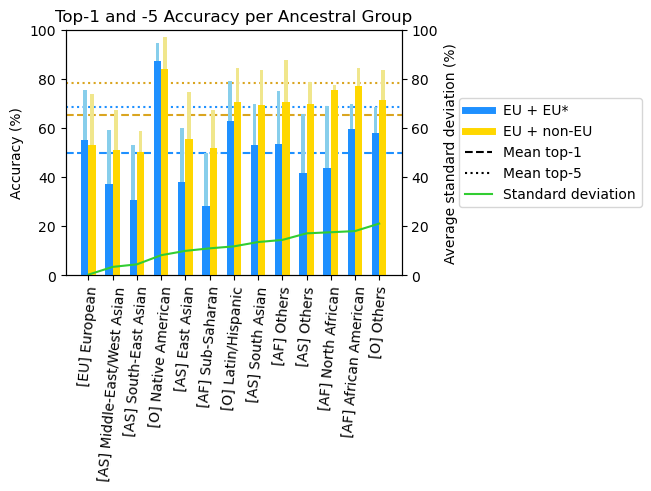

In [4]:
## Used for Fig 5a
# Data averaged over 5 runs (using random sampling from training splits) - GMDB v1.1.0

labels = np.array(["[AF] African American", "[AF] North African", "[AF] Sub-Saharan", "[AF] Others",
          
          "[AS] East Asian", "[AS] Middle-East/West Asian", "[AS] South Asian", "[AS] South-East Asian", "[AS] Others", 
          
          "[EU] European",
          "[O] Latin/Hispanic", "[O] Native American", "[O] Others"
         ])

# Top-1 accuracies of EU + non-EU, ordered by labels above
all_avg_t1 = np.array([
    77.08, 75.56, 51.87, 70.56,
    55.62, 50.99, 69.20, 50.40, 69.73,
    52.90,
    70.49, 84.14, 71.57
])
all_std_t1 =  np.array([ 18.04, 17.57, 11.02, 14.44, 9.99, 3.47, 13.58, 4.51, 17.12, 0.33, 11.82, 8.23, 21.09 ])

# Top-5 accuracies of EU + non-EU, ordered by labels above
all_avg_t5 = np.array([
    84.38, 77.64, 67.43, 87.78,
    74.48, 67.21, 83.40, 58.65, 78.56,
    73.74,
    84.26, 96.87, 83.43
])

# Top-1 accuracies of EU + EU*, ordered by labels above
eu_avg_t1 = np.array([
    59.38, 43.86, 28.27, 53.33,
    37.83, 37.06, 52.88, 30.75, 41.73,
    55.16,
    63.02, 87.27, 58.00
])

# Top-5 accuracies of EU + EU*, ordered by labels above
eu_avg_t5 = np.array([
    69.79, 68.79, 49.71, 75.00,
    59.91, 59.06, 69.87, 53.08, 65.76,
    75.60,
    79.03, 94.65, 68.71
])

## Sort options for labels
sort_title = "acc std top-1 EU + non-EU"
sort_idxs = np.argsort(all_std_t1)
second_y = all_std_t1[sort_idxs]
labels = labels[sort_idxs]

all_avg_t1 = all_avg_t1[sort_idxs]
all_avg_t5 = all_avg_t5[sort_idxs]
eu_avg_t1 = eu_avg_t1[sort_idxs]
eu_avg_t5 = eu_avg_t5[sort_idxs]

## End: Sorting

fig, ax = plt.subplots(layout='constrained')
# ax.grid(True, which='major', axis='y', zorder=0)

x = np.arange(len(labels))
width = 0.3

offset = 0.15
rects = ax.bar(x + offset, eu_avg_t5, width/2, label="Top-5", color="skyblue", zorder=3)
rects = ax.bar(x + offset, eu_avg_t1, width, label="Top-1", color="dodgerblue", zorder=3)

offset = width + 0.15
rects = ax.bar(x + offset, all_avg_t5, width/2, label="Top-5", color="khaki",zorder=3)
# ax.errorbar(x + offset+0.1, all_avg_t5, yerr=all_std_t5, fmt="none", capsize=2, color="black")
rects = ax.bar(x + offset, all_avg_t1, width, label="Top-1", color="gold", zorder=3)
# ax.errorbar(x + offset-0.1, all_avg_t1, yerr=all_std_t1, fmt="none", capsize=2, color="black")

ax.set_title(f"Top-1 and -5 Accuracy per Ancestral Group")
ax.set_ylabel("Accuracy (%)")
ax.set_xticks(x+width, labels, rotation=85)
# ax.legend()
ax.set_ylim(0, 100)

from matplotlib.lines import Line2D

custom_lines = [Line2D([0], [0], color="dodgerblue", lw=5, label='EU + EU*'),
                Line2D([0], [0], color="gold", lw=5, label='EU + non-EU')]

## Legend 
# ax.legend(custom_lines, ['EU + EU', 'EU + nonEU'], loc='lower left')
extra_lines = [plt.Line2D([], [], linestyle='--', label='Mean top-1', color='black'),
               plt.Line2D([], [], linestyle=':', label='Mean top-5', color='black'),
               plt.Line2D([], [], linestyle='-', label='Standard deviation', color='limegreen')]
ax.legend(handles=custom_lines + extra_lines, loc='center left', bbox_to_anchor=(1.15, 0.5))

plt.axhline(y=np.mean(all_avg_t1), color='goldenrod', ls='--', zorder=2)
plt.axhline(y=np.mean(all_avg_t5), color='goldenrod', ls=':', zorder=2)
print(np.mean(all_avg_t1))
print(np.mean(all_avg_t5))

plt.axhline(y=np.mean(eu_avg_t1), color='dodgerblue', ls='--', zorder=2)
plt.axhline(y=np.mean(eu_avg_t5), color='dodgerblue', ls=':', zorder=2)
print(np.mean(eu_avg_t1))
print(np.mean(eu_avg_t5))

# draw a vertical line at location X
# plt.axvline(x = 7.8, color = 'red')

# add second y-axis
ax2 = ax.twinx()
# ax2.plot(np.append(x, x[-1]+0.6), second_y+[second_y[-1]], color='limegreen')
ax2.plot(x+0.3, second_y, color='limegreen')
ax2.set_ylabel("Average standard deviation (%)")
ax2.set_ylim(0,100)

plt.savefig('../paper_plots/fig5a_classification_accuracy_anc.svg', dpi=300)
plt.show()

## Gallery set experiment - Gallery set expansion

We ran the evaluation script on different subsets of the gallery set: [EU only, Other only, EU + 10% other, EU + 20% other ..., EU + 100% other]

In [20]:
## AFTER 10 FOLDS
# results for each experiment .. [top_1, top_5, top_10, top_30]
# African (n=29)
# Asian (n=127)
# European (n=523)
# Others (n=69)
# Unknown (n=134)

# EU Only:
# African_only= np.array([0.62068966, 0.82758621, 0.82758621, 0.93103448]) #unused
African_accs = np.array([
    [37.93, 44.83, 51.72, 65.52],
    [51.38, 63.10, 67.24, 79.31],
    [55.86, 70.69, 74.83, 84.14],
    [58.97, 74.14, 75.86, 84.48],
    [59.31, 77.24, 78.97, 86.21],
    [63.79, 78.97, 79.66, 88.62],
    [58.62, 80.34, 80.34, 88.28],
    [62.07, 82.07, 82.41, 87.93],
    [63.45, 81.72, 81.72, 88.62],
    [63.10, 82.76, 82.76, 89.66],
    [62.07, 82.76, 82.76, 89.66]
])

# Asian_only= np.array([0.55905512, 0.77165354, 0.83464567, 0.88976378]) #unused
Asian_accs = np.array([
    [40.94, 60.63, 66.14, 76.38],
    [43.94, 64.09, 73.07, 82.44],
    [47.01, 68.58, 76.61, 85.75],
    [48.66, 70.31, 77.80, 85.43],
    [48.74, 72.52, 79.92, 87.95],
    [49.45, 72.91, 79.29, 87.95],
    [51.10, 75.75, 81.50, 88.19],
    [50.55, 76.69, 82.13, 89.13],
    [52.44, 78.35, 82.83, 89.21],
    [52.91, 79.45, 84.57, 89.29],
    [53.54, 80.31, 85.04, 89.76]
])

# European_only= np.array([0.40726577, 0.61950287, 0.66921606, 0.78585086]) #unused
European_accs = np.array([
    [55.45, 74.76, 82.60, 90.25],
    [55.62, 74.72, 82.47, 90.36],
    [55.54, 74.91, 82.52, 90.52],
    [55.54, 75.01, 82.39, 90.63],
    [55.72, 75.14, 82.47, 90.55],
    [55.49, 75.05, 82.41, 90.55],
    [55.53, 75.28, 82.73, 90.59],
    [55.68, 75.09, 82.72, 90.48],
    [55.60, 75.16, 82.50, 90.33],
    [55.60, 75.47, 82.52, 90.31],
    [55.64, 75.33, 82.60, 90.06]
])

# Others_only= np.array([0.72463768, 0.7826087 , 0.82608696, 0.89855072]) #unused
Others_accs = np.array([
    [60.87, 73.91, 76.81, 84.06],
    [64.06, 76.96, 78.84, 87.10],
    [65.65, 77.10, 78.70, 88.12],
    [65.94, 77.97, 80.29, 89.28],
    [69.42, 79.57, 82.17, 91.16],
    [69.42, 79.42, 81.45, 91.45],
    [70.00, 79.71, 80.72, 91.16],
    [72.17, 80.00, 81.30, 92.03],
    [72.32, 80.43, 80.43, 91.59],
    [72.90, 80.72, 80.87, 92.17],
    [73.91, 81.16, 81.16, 92.75]
])

# Unknown_only= np.array([0.52238806, 0.76865672, 0.82835821, 0.92537313]) #unused
Unknown_accs = np.array([
    [46.27, 61.94, 66.42, 74.63],
    [48.43, 65.52, 70.67, 79.63],
    [50.22, 67.54, 73.13, 83.36],
    [51.72, 68.58, 75.22, 85.82],
    [52.39, 70.37, 77.16, 87.46],
    [51.72, 71.57, 78.58, 88.36],
    [52.91, 71.94, 78.51, 89.33],
    [53.21, 72.16, 79.78, 89.93],
    [53.58, 72.39, 79.78, 90.9 ],
    [53.13, 72.46, 80.07, 91.19],
    [53.73, 73.13, 81.34, 91.04]
])

# standard deviations for the 10-fold experiment
African_stds = np.array([
    [5.55111512e-17, 1.11022302e-16, 1.11022302e-16, 1.11022302e-16],
    [8.64823186e-02, 3.79310345e-02, 3.53343130e-02, 3.77739695e-02],
    [3.71390676e-02, 4.93717968e-02, 4.09460072e-02, 4.13793103e-02],
    [9.43719461e-02, 5.17241379e-02, 4.08005502e-02, 3.53343130e-02],
    [6.68645498e-02, 3.83983749e-02, 3.60010569e-02, 3.77739695e-02],
    [4.69016224e-02, 2.86435306e-02, 3.25309694e-02, 3.46547435e-02],
    [5.11461965e-02, 2.69318954e-02, 2.69318954e-02, 3.16039703e-02],
    [4.08005502e-02, 1.37931034e-02, 1.03448276e-02, 1.72413793e-02],
    [3.83983749e-02, 2.20797387e-02, 2.20797387e-02, 2.20797387e-02],
    [3.10344828e-02, 1.11022302e-16, 1.11022302e-16, 2.22044605e-16],
    [0.00000000e+00, 1.11022302e-16, 1.11022302e-16, 2.22044605e-16]
])*100

Asian_stds = np.array([
    [5.55111512e-17, 1.11022302e-16, 1.11022302e-16, 1.11022302e-16],
    [1.44333093e-02, 1.46041236e-02, 1.60599040e-02, 1.72690647e-02],
    [1.83144935e-02, 1.47098753e-02, 1.93033869e-02, 1.91097025e-02],
    [1.88976378e-02, 3.13084966e-02, 2.07730802e-02, 9.48157053e-03],
    [2.42565698e-02, 2.21174361e-02, 1.69794163e-02, 1.31992556e-02],
    [1.88976378e-02, 1.96692850e-02, 1.86499516e-02, 8.66141732e-03],
    [1.84494087e-02, 2.16499639e-02, 1.99975198e-02, 7.87401575e-03],
    [2.27666650e-02, 1.80244459e-02, 1.57677042e-02, 6.86440779e-03],
    [9.44881890e-03, 1.80416366e-02, 1.44333093e-02, 9.34987566e-03],
    [9.18260141e-03, 8.94316275e-03, 5.22303117e-03, 5.22303117e-03],
    [0.00000000e+00, 1.11022302e-16, 0.00000000e+00, 0.00000000e+00]
])*100

European_stds = np.array([
    [1.11022302e-16, 1.11022302e-16, 0.00000000e+00, 2.22044605e-16],
    [3.57199650e-03, 3.60764097e-03, 2.27042870e-03, 2.73094777e-03],
    [2.60066358e-03, 5.65913904e-03, 3.93714346e-03, 1.94991186e-03],
    [3.33924459e-03, 4.01529637e-03, 3.67292021e-03, 3.31176063e-03],
    [6.35305840e-03, 5.13055750e-03, 5.86533906e-03, 2.86168825e-03],
    [4.74557310e-03, 5.35714177e-03, 3.52563842e-03, 1.75241900e-03],
    [3.44168260e-03, 3.73216468e-03, 3.20517297e-03, 2.53661552e-03],
    [3.50483801e-03, 4.68743812e-03, 3.84316467e-03, 2.67686424e-03],
    [2.81012208e-03, 3.36106995e-03, 4.29678873e-03, 1.52963671e-03],
    [2.05933645e-03, 2.10325048e-03, 2.59362523e-03, 8.76209502e-04],
    [1.11022302e-16, 1.11022302e-16, 0.00000000e+00, 2.22044605e-16]
])*100

Others_stds = np.array([
    [0.00000000e+00, 1.11022302e-16, 0.00000000e+00, 0.00000000e+00],
    [1.81014435e-02, 1.64606039e-02, 1.85597804e-02, 1.36724364e-02],
    [2.75362319e-02, 1.69013098e-02, 1.59420290e-02, 1.41999405e-02],
    [2.07504653e-02, 1.81014435e-02, 1.73913043e-02, 1.15942029e-02],
    [1.99242422e-02, 1.36724364e-02, 1.30434783e-02, 1.20385853e-02],
    [2.28691795e-02, 1.69013098e-02, 1.26344897e-02, 1.20385853e-02],
    [1.59420290e-02, 1.12260387e-02, 9.27989020e-03, 1.36724364e-02],
    [1.69013098e-02, 1.26344897e-02, 7.80458668e-03, 9.72203468e-03],
    [1.51308790e-02, 9.72203468e-03, 9.72203468e-03, 8.69565217e-03],
    [9.27989020e-03, 9.27989020e-03, 5.79710145e-03, 9.61340519e-03],
    [1.11022302e-16, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00]
])*100

Unknown_stds = np.array([
    [1.11022302e-16, 1.11022302e-16, 1.11022302e-16, 0.00000000e+00],
    [1.78012842e-02, 1.28392914e-02, 1.33705021e-02, 1.70338988e-02],
    [1.45665831e-02, 2.26968751e-02, 1.49253731e-02, 2.05867376e-02],
    [1.94746095e-02, 1.93022644e-02, 1.19402985e-02, 1.33496596e-02],
    [1.55825470e-02, 1.56716418e-02, 1.38412216e-02, 1.14643966e-02],
    [8.86144932e-03, 1.58131493e-02, 9.46908772e-03, 1.06588484e-02],
    [1.61614984e-02, 6.83966522e-03, 1.09678645e-02, 8.86144932e-03],
    [1.15852050e-02, 8.86144932e-03, 8.47598261e-03, 7.64697818e-03],
    [8.03755941e-03, 7.46268657e-03, 9.70149254e-03, 6.50581932e-03],
    [5.58456326e-03, 7.04028443e-03, 1.00400179e-02, 4.47761194e-03],
    [1.11022302e-16, 1.11022302e-16, 0.00000000e+00, 0.00000000e+00]
])*100

performance_labels = [
    # 'Others only',
    'EU only', 'EU + 10% others', 'EU + 20% others', 'EU + 30% others',
    'EU + 40% others', 'EU + 50% others', 'EU + 60% others', 'EU + 70% others', 'EU + 80% others',
    'EU + 90% others', 'EU + 100% others'
]

performances = []
performances_lower = []
performances_upper = []
# performances.append([African_only, Asian_only, European_only, Others_only, Unknown_only])
# performances_lower.append([African_only, Asian_only, European_only, Others_only, Unknown_only])
# performances_upper.append([African_only, Asian_only, European_only, Others_only, Unknown_only])

for i in range(len(performance_labels)):
    performances.append([African_accs[i], Asian_accs[i], European_accs[i], Others_accs[i], Unknown_accs[i]])
    performances_lower.append([African_accs[i]-African_stds[i], Asian_accs[i]-Asian_stds[i], European_accs[i]-European_stds[i], Others_accs[i]-Others_stds[i], Unknown_accs[i]-Unknown_stds[i]])
    performances_upper.append([African_accs[i]+African_stds[i], Asian_accs[i]+Asian_stds[i], European_accs[i]+European_stds[i], Others_accs[i]+Others_stds[i], Unknown_accs[i]+Unknown_stds[i]])

performances = np.array(performances)
performances_lower = np.array(performances_lower)
performances_upper = np.array(performances_upper)

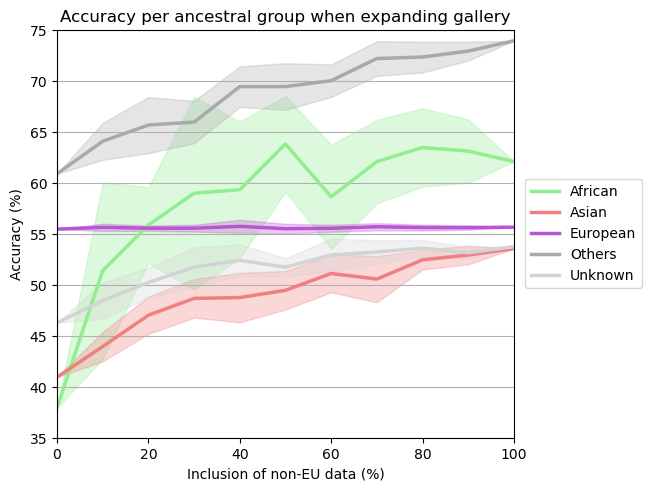

In [21]:
start_idx = 0 if len(performance_labels) == 11 else 1
fig, ax = plt.subplots(layout='constrained')

plt.ylim(35,75)
plt.xlim(0,10)

x = np.arange(len(performances[start_idx:,0,0]))
x_labels = np.linspace(0, 100, num=len(performances[start_idx:,0,0]), dtype=int)  # 11 labels ranging from 0 to 100
ticks_to_display = [0, 2, 4, 6, 8, 10]
plt.xticks(ticks_to_display, x_labels[ticks_to_display])

plt.plot(performances[start_idx:,0,0], linewidth=2.5, c='lightgreen', label="African")
plt.fill_between(x, performances_upper[start_idx:,0,0], performances_lower[start_idx:,0,0], color='lightgreen', alpha=0.3)
plt.plot(performances[start_idx:,1,0], linewidth=2.5, c='lightcoral', label="Asian")
plt.fill_between(x, performances_upper[start_idx:,1,0], performances_lower[start_idx:,1,0], color='lightcoral', alpha=0.3)
plt.plot(performances[start_idx:,2,0], linewidth=2.5, c='mediumorchid', label="European")
plt.fill_between(x, performances_upper[start_idx:,2,0], performances_lower[start_idx:,2,0], color='mediumorchid', alpha=0.3)
plt.plot(performances[start_idx:,3,0], linewidth=2.5, c='darkgray', label="Others")
plt.fill_between(x, performances_upper[start_idx:,3,0], performances_lower[start_idx:,3,0], color='darkgray', alpha=0.3)
plt.plot(performances[start_idx:,4,0], linewidth=2.5, c='lightgray', label="Unknown")
plt.fill_between(x, performances_upper[start_idx:,4,0], performances_lower[start_idx:,4,0], color='lightgray', alpha=0.3)
handles, labels = plt.gca().get_legend_handles_labels()

# plt.plot(performances[1:,0,1]*100, linewidth=1.5, c='lightgreen', linestyle='--')
# plt.plot(performances[1:,1,1]*100, linewidth=1.5, c='lightcoral', linestyle='--')
# plt.plot(performances[1:,2,1]*100, linewidth=1.5, c='mediumorchid', linestyle='--')
# plt.plot(performances[1:,3,1]*100, linewidth=1.5, c='darkgray', linestyle='--')
# plt.plot(performances[1:,4,1]*100, linewidth=1.5, c='lightgray', linestyle='--')

# plt.xlabel("Proportion of available diverse ancestral data (%)")
plt.xlabel("Inclusion of non-EU data (%)")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy per ancestral group when expanding gallery")

extra_lines = [
#     plt.Line2D([], [], linestyle='-', label='Top-1', color='black', linewidth=2.5),
#     plt.Line2D([], [], linestyle='--', label='Top-5', color='black', linewidth=1.5)
               ]
labels.append(['Top-1', 'Top-5'])
plt.legend(handles=handles+extra_lines, loc='center left', bbox_to_anchor=(1.01, 0.5))

plt.grid(True, which='major', axis='y', linestyle='-')

plt.savefig('../paper_plots/fig5b_gallery_expansion.svg', dpi=300)
plt.show()

In [22]:
freqs_others_diverse = [1385, 1398, 1383, 1399, 1405]  # non-EU; mean: 1394.0
freqs_eu_divers = [3309, 3336, 3312, 3271, 3336]  # EU-base; mean: 3312.8
freqs_eu_only = [4694, 4734, 4695, 4670, 4741]  # EU-total; mean: 4706.8